# Codigo Comparativo Modelos de Series Temporales (ARMA, ARIMA, SARIMA, SARIMAX)

### 0. Carga y union de los resultados de los 4 modelos

In [30]:
import pandas as pd
import numpy as np

# =================================================================================== #
# 0. LECTURA Y UNIFICACION DE LOS 4 ARCHIVOS DE PREDICCIONES
# =================================================================================== #
# Cada csv fue generado de forma independiente por el cuaderno de su modelo
# y contiene: Precio_Real, Prediccion_<MODELO>, Diferencia_<MODELO>, hour, month

ruta_arma    = '../ARMA/predicciones_arma_2024.csv'
ruta_arima   = '../ARIMA/predicciones_arima_2024.csv'
ruta_sarima  = '../SARIMA/predicciones_sarima_2024.csv'
ruta_sarimax = '../SARIMAX/predicciones_sarimax_2024.csv'

df_arma    = pd.read_csv(ruta_arma,    index_col=0, parse_dates=True)
df_arima   = pd.read_csv(ruta_arima,   index_col=0, parse_dates=True)
df_sarima  = pd.read_csv(ruta_sarima,  index_col=0, parse_dates=True)
df_sarimax = pd.read_csv(ruta_sarimax, index_col=0, parse_dates=True)

# Partimos del csv de SARIMAX (Precio_Real y columnas temporales identicas en los 4)
# y le vamos añadiendo la columna de prediccion de cada modelo
df_resultados_csv = df_sarimax[['Precio_Real', 'hour', 'month']].copy()

df_resultados_csv['Prediccion_ARMA']    = df_arma['Prediccion_ARMA']
df_resultados_csv['Prediccion_ARIMA']   = df_arima['Prediccion_ARIMA']
df_resultados_csv['Prediccion_SARIMA']  = df_sarima['Prediccion_SARIMA']
df_resultados_csv['Prediccion_SARIMAX'] = df_sarimax['Prediccion_SARIMAX']

#df_resultados_csv['Diferencia_ARMA']    = df_resultados_csv['Precio_Real'] - df_resultados_csv['Prediccion_ARMA']
#df_resultados_csv['Diferencia_ARIMA']   = df_resultados_csv['Precio_Real'] - df_resultados_csv['Prediccion_ARIMA']
#df_resultados_csv['Diferencia_SARIMA']  = df_resultados_csv['Precio_Real'] - df_resultados_csv['Prediccion_SARIMA']
#df_resultados_csv['Diferencia_SARIMAX'] = df_resultados_csv['Precio_Real'] - df_resultados_csv['Prediccion_SARIMAX']

# Guardamos el csv unificado para que las siguientes celdas trabajen igual que en los cuadernos individuales
df_resultados_csv.to_csv('predicciones_comparativa_series_temporales_2024.csv')

print(df_resultados_csv.head(3))

                     Precio_Real  hour  month  Prediccion_ARMA  \
datetime                                                         
2024-01-01 00:00:00        63.33     0      1        71.636593   
2024-01-01 01:00:00        50.09     1      1        72.096770   
2024-01-01 02:00:00        47.50     2      1        72.828655   

                     Prediccion_ARIMA  Prediccion_SARIMA  Prediccion_SARIMAX  
datetime                                                                      
2024-01-01 00:00:00         66.878005          58.577427           58.333003  
2024-01-01 01:00:00         61.574168          50.092681           49.666716  
2024-01-01 02:00:00         57.125835          48.660150           47.773971  


### Visualizacion de las prediciones en una ventana de tiempo

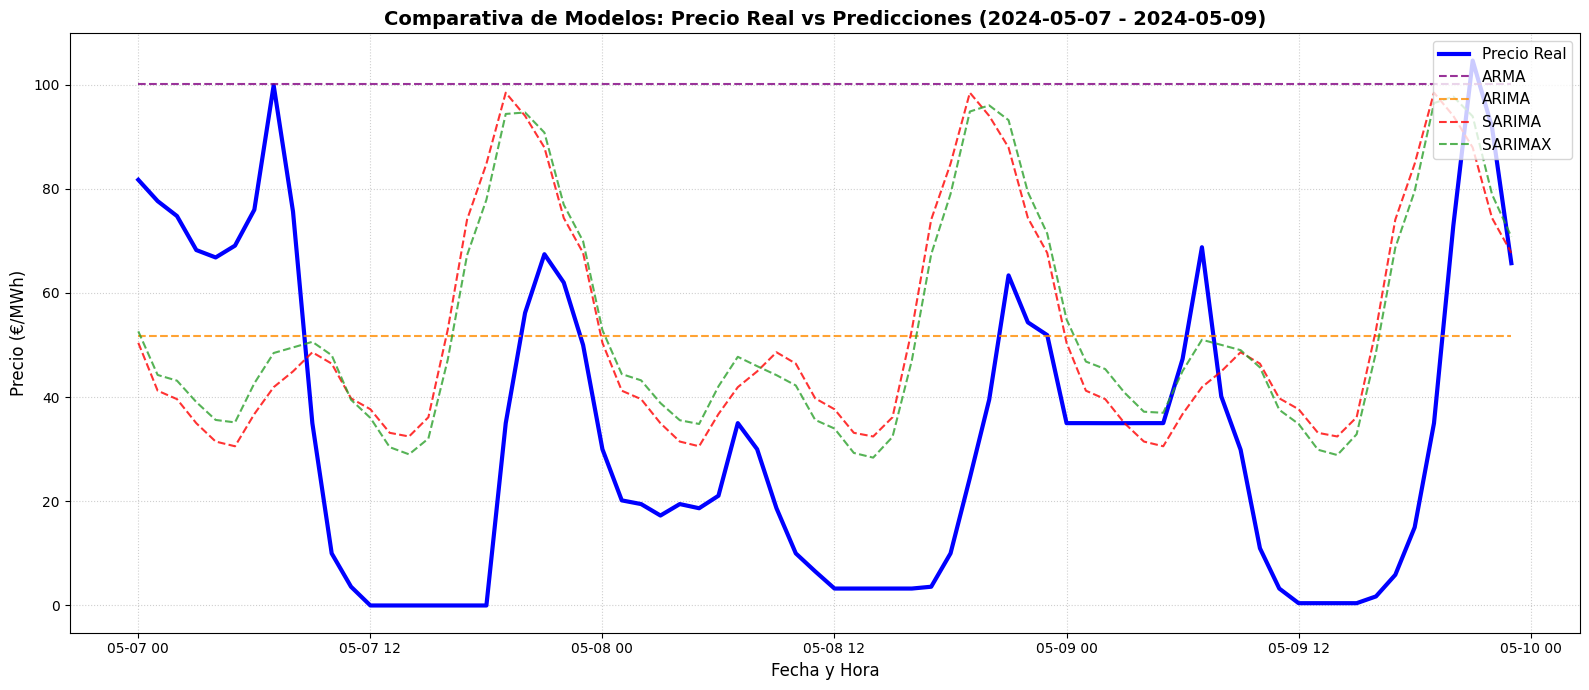

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

# =================================================================================== #
# 7. VISUALIZACION DE RESULTADOS (LOS 4 MODELOS)
# =================================================================================== #
# Filtramos un tramo corto (ej. un dia concreto de 2024)
df_resultados_csv = pd.read_csv('predicciones_comparativa_series_temporales_2024.csv', index_col=0, parse_dates=True)
df_plot = df_resultados_csv.loc['2024-05-07':'2024-05-09'] #ejemplo: Cambiar a '2024-01-01':'2024-01-15' para ver solo la primera quincena

plt.figure(figsize=(16, 7))

# 1. Linea del Precio Real (Azul, continua y mas gruesa para que destaque)
plt.plot(df_plot.index, df_plot['Precio_Real'], 
         label='Precio Real', color='blue', linewidth=3)

# 2. Linea ARMA (Morado, punteada)
plt.plot(df_plot.index, df_plot['Prediccion_ARMA'], 
         label='ARMA', color='purple', linestyle='--', linewidth=1.5, alpha=0.8)

# 3. Linea ARIMA (Naranja, punteada)
plt.plot(df_plot.index, df_plot['Prediccion_ARIMA'], 
         label='ARIMA', color='darkorange', linestyle='--', linewidth=1.5, alpha=0.8)

# 4. Linea SARIMA (Rojo, punteada)
plt.plot(df_plot.index, df_plot['Prediccion_SARIMA'], 
         label='SARIMA', color='red', linestyle='--', linewidth=1.5, alpha=0.8)

# 5. Linea SARIMAX (Verde, punteada)
plt.plot(df_plot.index, df_plot['Prediccion_SARIMAX'], 
         label='SARIMAX', color='#2ca02c', linestyle='--', linewidth=1.5, alpha=0.8)

# Añadimos titulos y diseño
plt.title('Comparativa de Modelos: Precio Real vs Predicciones (' + str(df_plot.index[0].date()) + ' - ' + str(df_plot.index[-1].date()) + ')', fontsize=14, fontweight='bold')
plt.xlabel('Fecha y Hora', fontsize=12)
plt.ylabel('Precio (€/MWh)', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()

# Guardamos y mostramos
plt.savefig('grafico_comparativa_series_temporales_(' + str(df_plot.index[0].date()) + ' - ' + str(df_plot.index[-1].date()) + ')_2024.png', dpi=300)
plt.show()

#### Grafica del MAE (error medio)

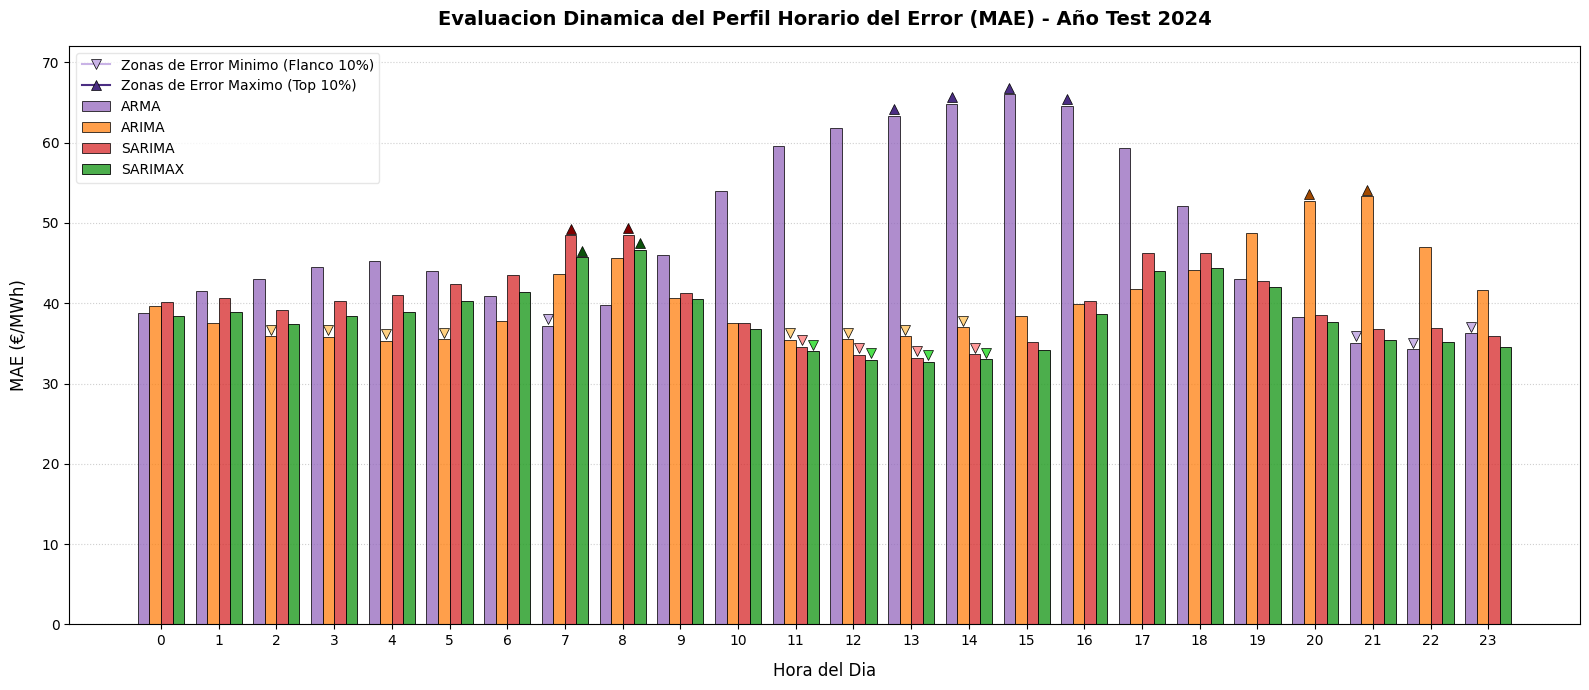

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error

# =================================================================================== #
# 8. ANALISIS HORARIO COMPARATIVO DEL ERROR (LOS 4 MODELOS - DESDE CSV)
# =================================================================================== #

# 1. Carga y calculo dinamico de metricas por hora
df_resultados_csv = pd.read_csv('predicciones_comparativa_series_temporales_2024.csv', index_col=0, parse_dates=True)
mae_arma    = df_resultados_csv.groupby('hour').apply(lambda x: mean_absolute_error(x['Precio_Real'], x['Prediccion_ARMA']))
mae_arima   = df_resultados_csv.groupby('hour').apply(lambda x: mean_absolute_error(x['Precio_Real'], x['Prediccion_ARIMA']))
mae_sarima  = df_resultados_csv.groupby('hour').apply(lambda x: mean_absolute_error(x['Precio_Real'], x['Prediccion_SARIMA']))
mae_sarimax = df_resultados_csv.groupby('hour').apply(lambda x: mean_absolute_error(x['Precio_Real'], x['Prediccion_SARIMAX']))

fig, ax = plt.subplots(figsize=(16, 7))

horas = np.arange(24)
ancho_barra = 0.20

# 2. Dibujo de las barras base
barras_arma    = ax.bar(horas - 1.5*ancho_barra, mae_arma,    width=ancho_barra, label='ARMA',    color='#9467bd', alpha=0.75, edgecolor='black', linewidth=0.7)
barras_arima   = ax.bar(horas - 0.5*ancho_barra, mae_arima,   width=ancho_barra, label='ARIMA',   color='#ff7f0e', alpha=0.75, edgecolor='black', linewidth=0.7)
barras_sarima  = ax.bar(horas + 0.5*ancho_barra, mae_sarima,  width=ancho_barra, label='SARIMA',  color='#d62728', alpha=0.75, edgecolor='black', linewidth=0.7)
barras_sarimax = ax.bar(horas + 1.5*ancho_barra, mae_sarimax, width=ancho_barra, label='SARIMAX', color='#2ca02c', alpha=0.85, edgecolor='black', linewidth=0.7)

# ---------------------------------------------------------------------------------------
# IDENTIFICACION Y MARCADO DINAMICO CON COLORES ASOCIADOS AL MODELO
# ---------------------------------------------------------------------------------------
modelos_data = [
    {
        'mae': mae_arma, 
        'desplazamiento': -1.5*ancho_barra, 
        'color_alto': '#4b2e83',      # Morado oscuro para el peor ARMA
        'color_bajo': '#c9b3e6'       # Morado claro para el mejor ARMA
    },
    {
        'mae': mae_arima, 
        'desplazamiento': -0.5*ancho_barra, 
        'color_alto': '#a14900',      # Marron teja para el peor ARIMA
        'color_bajo': '#ffd080'       # Naranja claro para el mejor ARIMA
    },
    {
        'mae': mae_sarima, 
        'desplazamiento': 0.5*ancho_barra, 
        'color_alto': '#7f0000',      # Rojo oscuro para el peor SARIMA
        'color_bajo': '#ff9999'       # Rojo claro para el mejor SARIMA
    },
    {
        'mae': mae_sarimax, 
        'desplazamiento': 1.5*ancho_barra, 
        'color_alto': '#0b520b',      # Verde bosque para el peor SARIMAX
        'color_bajo': '#4ee04e'       # Verde claro para el mejor SARIMAX
    }
]

# Controladores para no duplicar los nombres genericos en la leyenda
legend_max_added = False
legend_min_added = False

for mod in modelos_data:
    mae = mod['mae']
    desplazamiento = mod['desplazamiento']
    
    max_val = mae.max()
    min_val = mae.min()
    rango_total = max_val - min_val
    
    limite_alto = max_val - (0.10 * rango_total)
    limite_bajo = min_val + (0.10 * rango_total)
    
    for hora in horas:
        valor_mae = mae[hora]
        posicion_x = hora + desplazamiento
        
        # Caso A: Errores maximos o en el 10% superior (Flecha hacia arriba '^')
        if valor_mae >= limite_alto:
            label_text = 'Zonas de Error Maximo (Top 10%)' if not legend_max_added else ""
            ax.plot(posicion_x, valor_mae + 0.8, marker='^', color=mod['color_alto'], 
                    markersize=7, markeredgecolor='black', markeredgewidth=0.5, label=label_text)
            legend_max_added = True
            
        # Caso B: Errores minimos o en el 10% inferior (Flecha hacia abajo 'v')
        elif valor_mae <= limite_bajo:
            label_text = 'Zonas de Error Minimo (Flanco 10%)' if not legend_min_added else ""
            ax.plot(posicion_x, valor_mae + 0.8, marker='v', color=mod['color_bajo'], 
                    markersize=7, markeredgecolor='black', markeredgewidth=0.5, label=label_text)
            legend_min_added = True

# ---------------------------------------------------------------------------------------
# DISEÑO, FORMATO ACADEMICO Y REJILLA
# ---------------------------------------------------------------------------------------
ax.set_title('Evaluacion Dinamica del Perfil Horario del Error (MAE) - Año Test 2024', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Hora del Dia', fontsize=12, labelpad=10)
ax.set_ylabel('MAE (€/MWh)', fontsize=12, labelpad=10)
ax.set_xticks(horas)

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle=':', alpha=0.6)

# Leyenda unificada a la izquierda
ax.legend(loc='upper left', fontsize=10, frameon=True, facecolor='white', edgecolor='#e0e0e0')

# Limites del eje Y holgados para que no se solape con la leyenda
error_max_global = max(mae_arma.max(), mae_arima.max(), mae_sarima.max(), mae_sarimax.max())
ax.set_ylim(0, error_max_global + 6)

plt.tight_layout()

# Guardado automatico
plt.savefig('grafico_comparativa_media_error_horario_series_temporales_2024.png', dpi=300)
plt.show()

#### Grafica del Error Modal

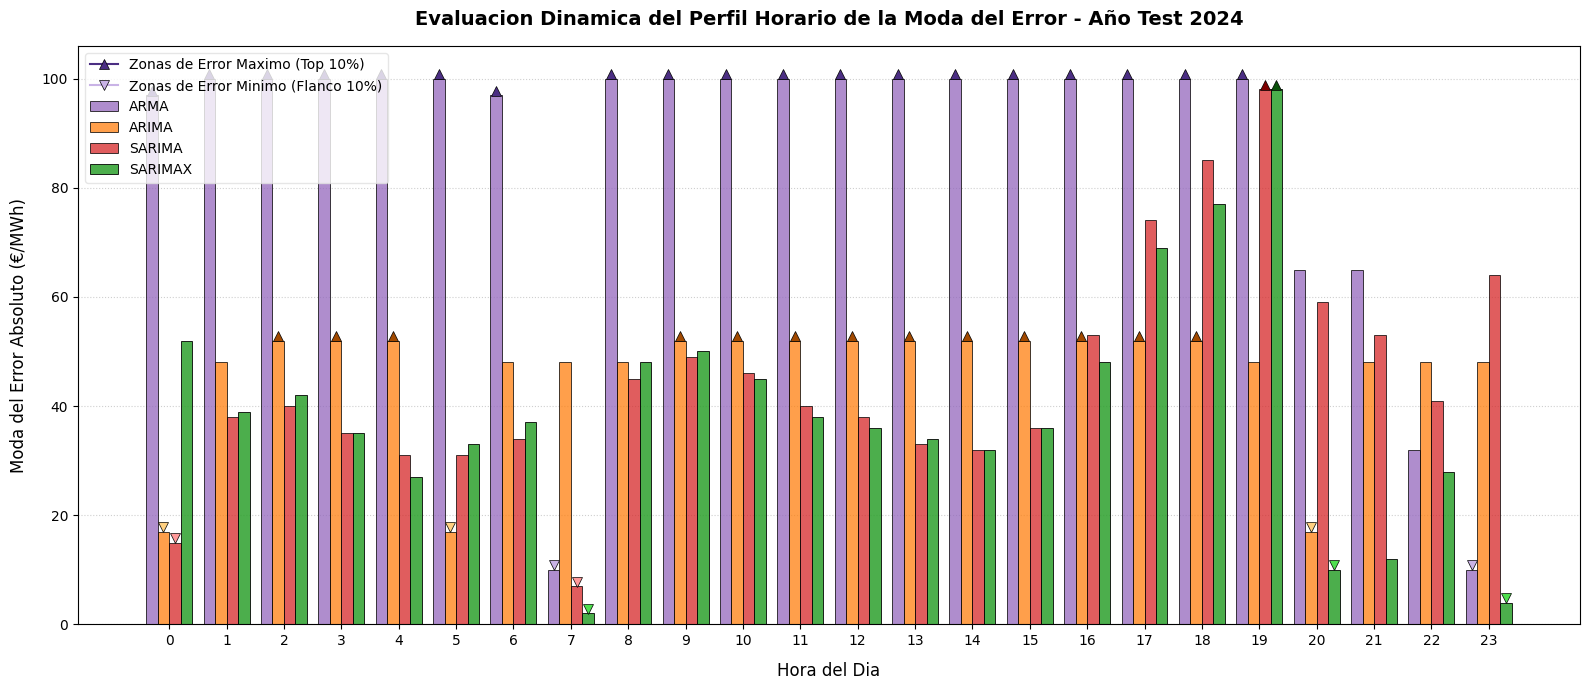

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =================================================================================== #
# 8. ANALISIS HORARIO COMPARATIVO DEL ERROR (MODA DEL ERROR ABSOLUTO - DESDE CSV)
# =================================================================================== #

# 1. Carga del archivo CSV de resultados
df_resultados_csv = pd.read_csv('predicciones_comparativa_series_temporales_2024.csv', index_col=0, parse_dates=True)

# Funcion interna para calcular la moda del error absoluto redondeado a enteros
def calcular_moda_error(df, col_pred):
    # Calculamos el error absoluto por cada fila
    error_absoluto = (df['Precio_Real'] - df[col_pred]).abs()
    # Redondeamos a enteros para permitir que existan valores repetidos (Moda)
    error_redondeado = error_absoluto.round(0)
    # Agrupamos por hora y extraemos el valor mas frecuente (la moda)
    return error_redondeado.groupby(df['hour']).apply(lambda x: x.mode().iloc[0] if not x.empty else 0)

# Calculo dinamico de la moda del error por hora para cada modelo
moda_arma    = calcular_moda_error(df_resultados_csv, 'Prediccion_ARMA')
moda_arima   = calcular_moda_error(df_resultados_csv, 'Prediccion_ARIMA')
moda_sarima  = calcular_moda_error(df_resultados_csv, 'Prediccion_SARIMA')
moda_sarimax = calcular_moda_error(df_resultados_csv, 'Prediccion_SARIMAX')

fig, ax = plt.subplots(figsize=(16, 7))

horas = np.arange(24)
ancho_barra = 0.20

# 2. Dibujo de las barras base
barras_arma    = ax.bar(horas - 1.5*ancho_barra, moda_arma,    width=ancho_barra, label='ARMA',    color='#9467bd', alpha=0.75, edgecolor='black', linewidth=0.7)
barras_arima   = ax.bar(horas - 0.5*ancho_barra, moda_arima,   width=ancho_barra, label='ARIMA',   color='#ff7f0e', alpha=0.75, edgecolor='black', linewidth=0.7)
barras_sarima  = ax.bar(horas + 0.5*ancho_barra, moda_sarima,  width=ancho_barra, label='SARIMA',  color='#d62728', alpha=0.75, edgecolor='black', linewidth=0.7)
barras_sarimax = ax.bar(horas + 1.5*ancho_barra, moda_sarimax, width=ancho_barra, label='SARIMAX', color='#2ca02c', alpha=0.85, edgecolor='black', linewidth=0.7)

# ---------------------------------------------------------------------------------------
# IDENTIFICACION Y MARCADO DINAMICO CON COLORES ASOCIADOS AL MODELO
# ---------------------------------------------------------------------------------------
modelos_data = [
    {
        'valores': moda_arma, 
        'desplazamiento': -1.5*ancho_barra, 
        'color_alto': '#4b2e83',      # Morado oscuro para el peor ARMA
        'color_bajo': '#c9b3e6'       # Morado claro para el mejor ARMA
    },
    {
        'valores': moda_arima, 
        'desplazamiento': -0.5*ancho_barra, 
        'color_alto': '#a14900',      # Marron teja para el peor ARIMA
        'color_bajo': '#ffd080'       # Naranja claro para el mejor ARIMA
    },
    {
        'valores': moda_sarima, 
        'desplazamiento': 0.5*ancho_barra, 
        'color_alto': '#7f0000',      # Rojo oscuro para el peor SARIMA
        'color_bajo': '#ff9999'       # Rojo claro para el mejor SARIMA
    },
    {
        'valores': moda_sarimax, 
        'desplazamiento': 1.5*ancho_barra, 
        'color_alto': '#0b520b',      # Verde bosque para el peor SARIMAX
        'color_bajo': '#4ee04e'       # Verde claro para el mejor SARIMAX
    }
]

# Controladores para no duplicar los nombres genericos en la leyenda
legend_max_added = False
legend_min_added = False

for mod in modelos_data:
    valores = mod['valores']
    desplazamiento = mod['desplazamiento']
    
    max_val = valores.max()
    min_val = valores.min()
    rango_total = max_val - min_val
    
    limite_alto = max_val - (0.10 * rango_total)
    limite_bajo = min_val + (0.10 * rango_total)
    
    for hora in horas:
        valor_actual = valores[hora]
        posicion_x = hora + desplazamiento
        
        # Caso A: Valores maximos o en el 10% superior (Flecha hacia arriba '^')
        if valor_actual >= limite_alto:
            label_text = 'Zonas de Error Maximo (Top 10%)' if not legend_max_added else ""
            ax.plot(posicion_x, valor_actual + 0.8, marker='^', color=mod['color_alto'], 
                    markersize=7, markeredgecolor='black', markeredgewidth=0.5, label=label_text)
            legend_max_added = True
            
        # Caso B: Valores minimos o en el 10% inferior (Flecha hacia abajo 'v')
        elif valor_actual <= limite_bajo:
            label_text = 'Zonas de Error Minimo (Flanco 10%)' if not legend_min_added else ""
            ax.plot(posicion_x, valor_actual + 0.8, marker='v', color=mod['color_bajo'], 
                    markersize=7, markeredgecolor='black', markeredgewidth=0.5, label=label_text)
            legend_min_added = True

# ---------------------------------------------------------------------------------------
# DISEÑO, FORMATO ACADEMICO Y REJILLA
# ---------------------------------------------------------------------------------------
ax.set_title('Evaluacion Dinamica del Perfil Horario de la Moda del Error - Año Test 2024', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Hora del Dia', fontsize=12, labelpad=10)
ax.set_ylabel('Moda del Error Absoluto (€/MWh)', fontsize=12, labelpad=10)
ax.set_xticks(horas)

ax.set_axisbelow(True)
ax.grid(axis='y', linestyle=':', alpha=0.6)

# Leyenda unificada a la izquierda
ax.legend(loc='upper left', fontsize=10, frameon=True, facecolor='white', edgecolor='#e0e0e0')

# Limites del eje Y holgados para que no se solape con la leyenda
error_max_global = max(moda_arma.max(), moda_arima.max(), moda_sarima.max(), moda_sarimax.max())
ax.set_ylim(0, error_max_global + 6)

plt.tight_layout()

# Guardado automatico con nuevo nombre descriptivo
plt.savefig('grafico_comparativa_moda_error_horario_series_temporales_2024.png', dpi=300)
plt.show()

#### Grafica de Errores Extremos

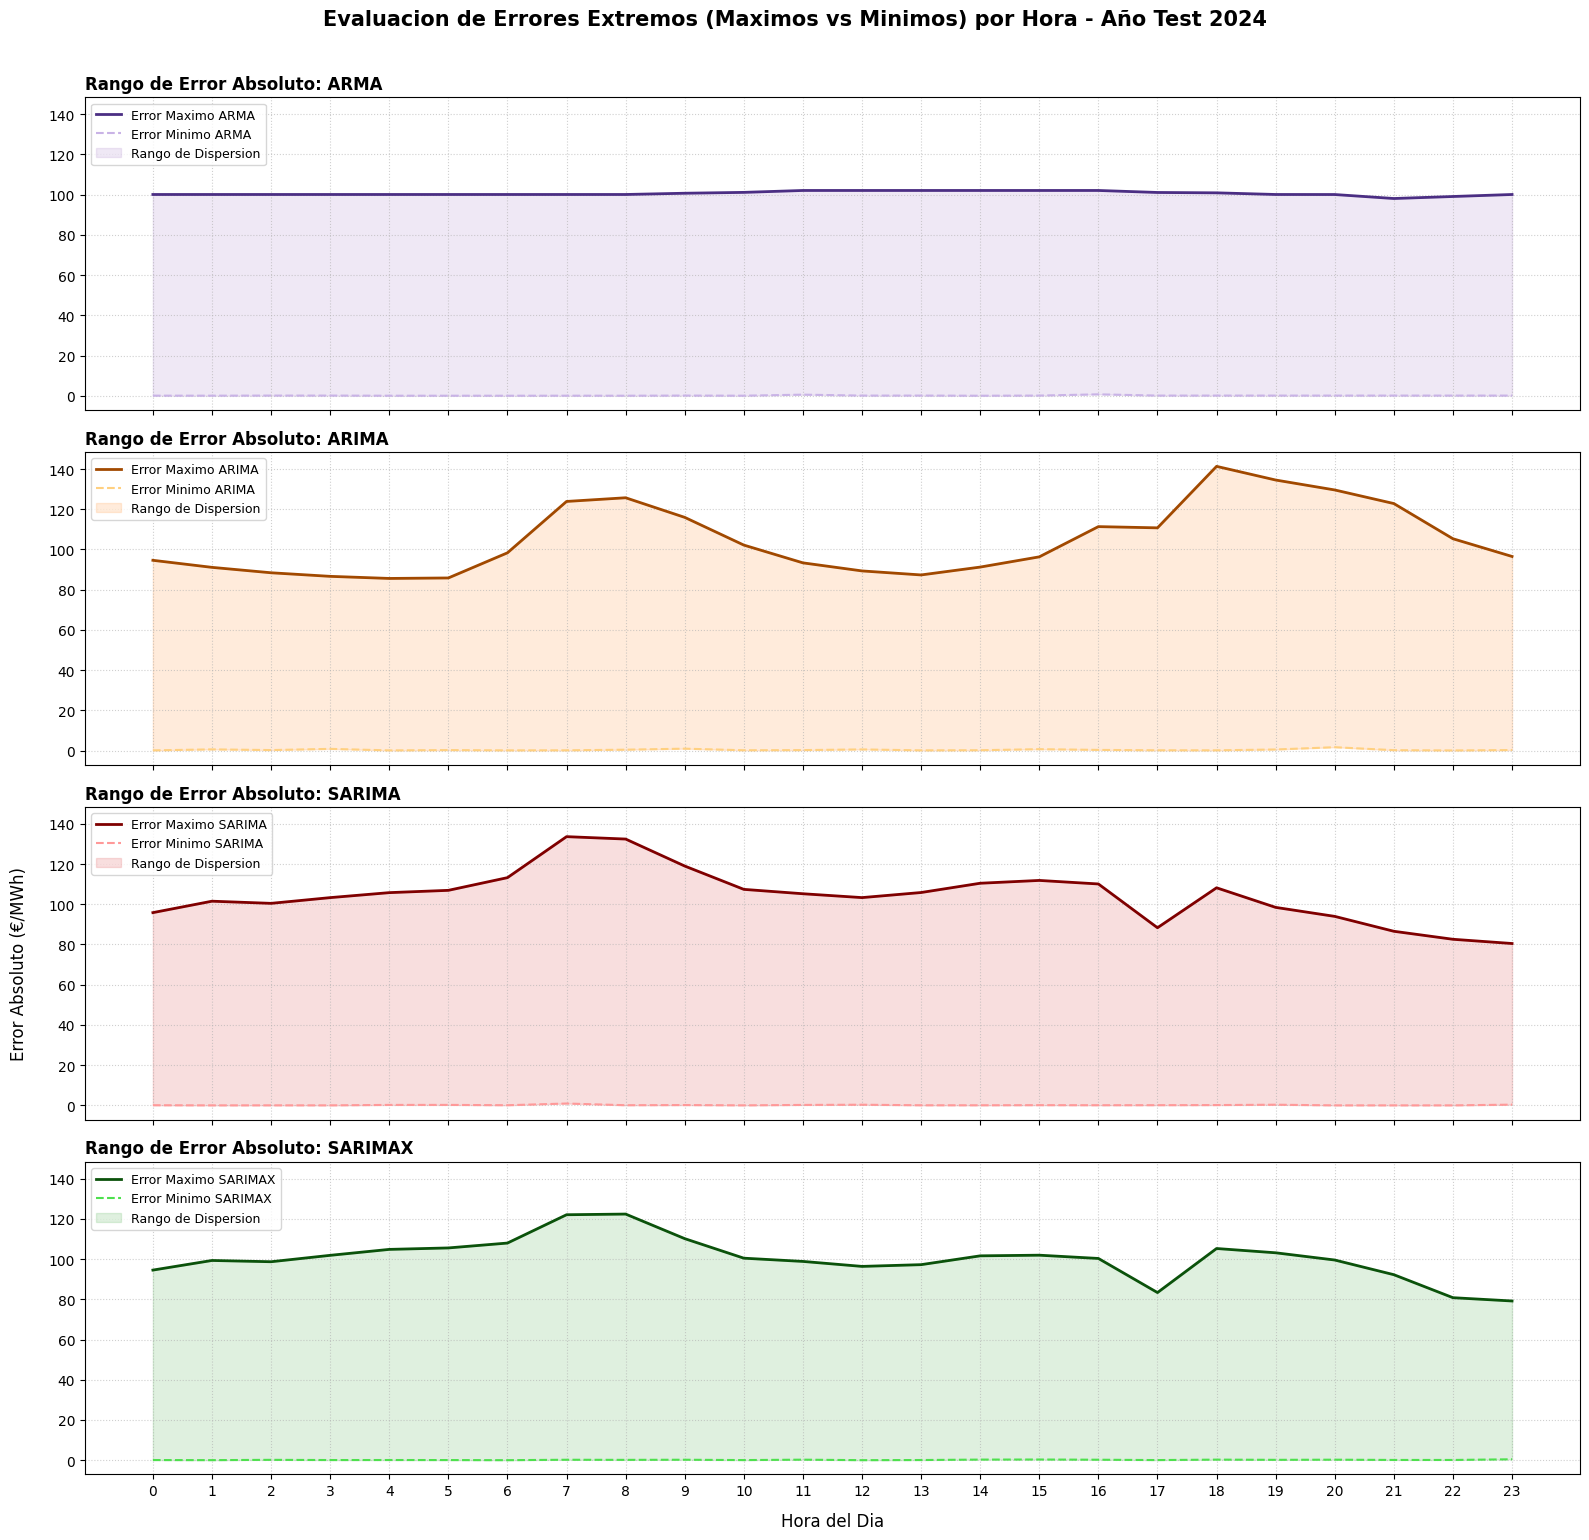

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =================================================================================== #
# 9. ANALISIS HORARIO DE ERRORES EXTREMOS (MAXIMOS Y MINIMOS DESDE CSV)
# =================================================================================== #

# 1. Carga del archivo CSV de resultados
df_resultados_csv = pd.read_csv('predicciones_comparativa_series_temporales_2024.csv', index_col=0, parse_dates=True)

# Funcion para extraer el error absoluto maximo y minimo por hora
def calcular_errores_extremos(df, col_pred):
    error_absoluto = (df['Precio_Real'] - df[col_pred]).abs()
    err_max = error_absoluto.groupby(df['hour']).max()
    err_min = error_absoluto.groupby(df['hour']).min()
    return err_max, err_min

# Calculo dinamico para cada modelo
max_arma, min_arma       = calcular_errores_extremos(df_resultados_csv, 'Prediccion_ARMA')
max_arima, min_arima     = calcular_errores_extremos(df_resultados_csv, 'Prediccion_ARIMA')
max_sarima, min_sarima   = calcular_errores_extremos(df_resultados_csv, 'Prediccion_SARIMA')
max_sarimax, min_sarimax = calcular_errores_extremos(df_resultados_csv, 'Prediccion_SARIMAX')

horas = np.arange(24)

# Creamos 4 subgraficas verticales que comparten el mismo eje Y para una comparacion justa
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(16, 16), sharex=True, sharey=True)

# ---------------------------------------------------------------------------------------
# PANEL 1: ARMA (Morado)
# ---------------------------------------------------------------------------------------
ax1.plot(horas, max_arma, color='#4b2e83', linestyle='-', linewidth=2, label='Error Maximo ARMA')
ax1.plot(horas, min_arma, color='#c9b3e6', linestyle='--', linewidth=1.5, label='Error Minimo ARMA')
ax1.fill_between(horas, min_arma, max_arma, color='#9467bd', alpha=0.15, label='Rango de Dispersion')
ax1.set_title('Rango de Error Absoluto: ARMA', fontsize=12, fontweight='bold', loc='left')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='upper left', fontsize=9)

# ---------------------------------------------------------------------------------------
# PANEL 2: ARIMA (Naranja)
# ---------------------------------------------------------------------------------------
ax2.plot(horas, max_arima, color='#a14900', linestyle='-', linewidth=2, label='Error Maximo ARIMA')
ax2.plot(horas, min_arima, color='#ffd080', linestyle='--', linewidth=1.5, label='Error Minimo ARIMA')
ax2.fill_between(horas, min_arima, max_arima, color='#ff7f0e', alpha=0.15, label='Rango de Dispersion')
ax2.set_title('Rango de Error Absoluto: ARIMA', fontsize=12, fontweight='bold', loc='left')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(loc='upper left', fontsize=9)

# ---------------------------------------------------------------------------------------
# PANEL 3: SARIMA (Rojo)
# ---------------------------------------------------------------------------------------
ax3.plot(horas, max_sarima, color='#7f0000', linestyle='-', linewidth=2, label='Error Maximo SARIMA')
ax3.plot(horas, min_sarima, color='#ff9999', linestyle='--', linewidth=1.5, label='Error Minimo SARIMA')
ax3.fill_between(horas, min_sarima, max_sarima, color='#d62728', alpha=0.15, label='Rango de Dispersion')
ax3.set_title('Rango de Error Absoluto: SARIMA', fontsize=12, fontweight='bold', loc='left')
ax3.grid(True, linestyle=':', alpha=0.6)
ax3.legend(loc='upper left', fontsize=9)
ax3.set_ylabel('Error Absoluto (€/MWh)', fontsize=12, labelpad=15)

# ---------------------------------------------------------------------------------------
# PANEL 4: SARIMAX (Verde)
# ---------------------------------------------------------------------------------------
ax4.plot(horas, max_sarimax, color='#0b520b', linestyle='-', linewidth=2, label='Error Maximo SARIMAX')
ax4.plot(horas, min_sarimax, color='#4ee04e', linestyle='--', linewidth=1.5, label='Error Minimo SARIMAX')
ax4.fill_between(horas, min_sarimax, max_sarimax, color='#2ca02c', alpha=0.15, label='Rango de Dispersion')
ax4.set_title('Rango de Error Absoluto: SARIMAX', fontsize=12, fontweight='bold', loc='left')
ax4.grid(True, linestyle=':', alpha=0.6)
ax4.legend(loc='upper left', fontsize=9)
ax4.set_xlabel('Hora del Dia', fontsize=12, labelpad=10)

# Configuracion de los ejes comunes
plt.xticks(horas)
fig.suptitle('Evaluacion de Errores Extremos (Maximos vs Minimos) por Hora - Año Test 2024', fontsize=15, fontweight='bold', y=0.96)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Guardado automatico con alta resolucion para la memoria
plt.savefig('grafico_errores_extremos_horarios_series_temporales_2024.png', dpi=300)
plt.show()

#### Comparativa Grafica de los datos horarios

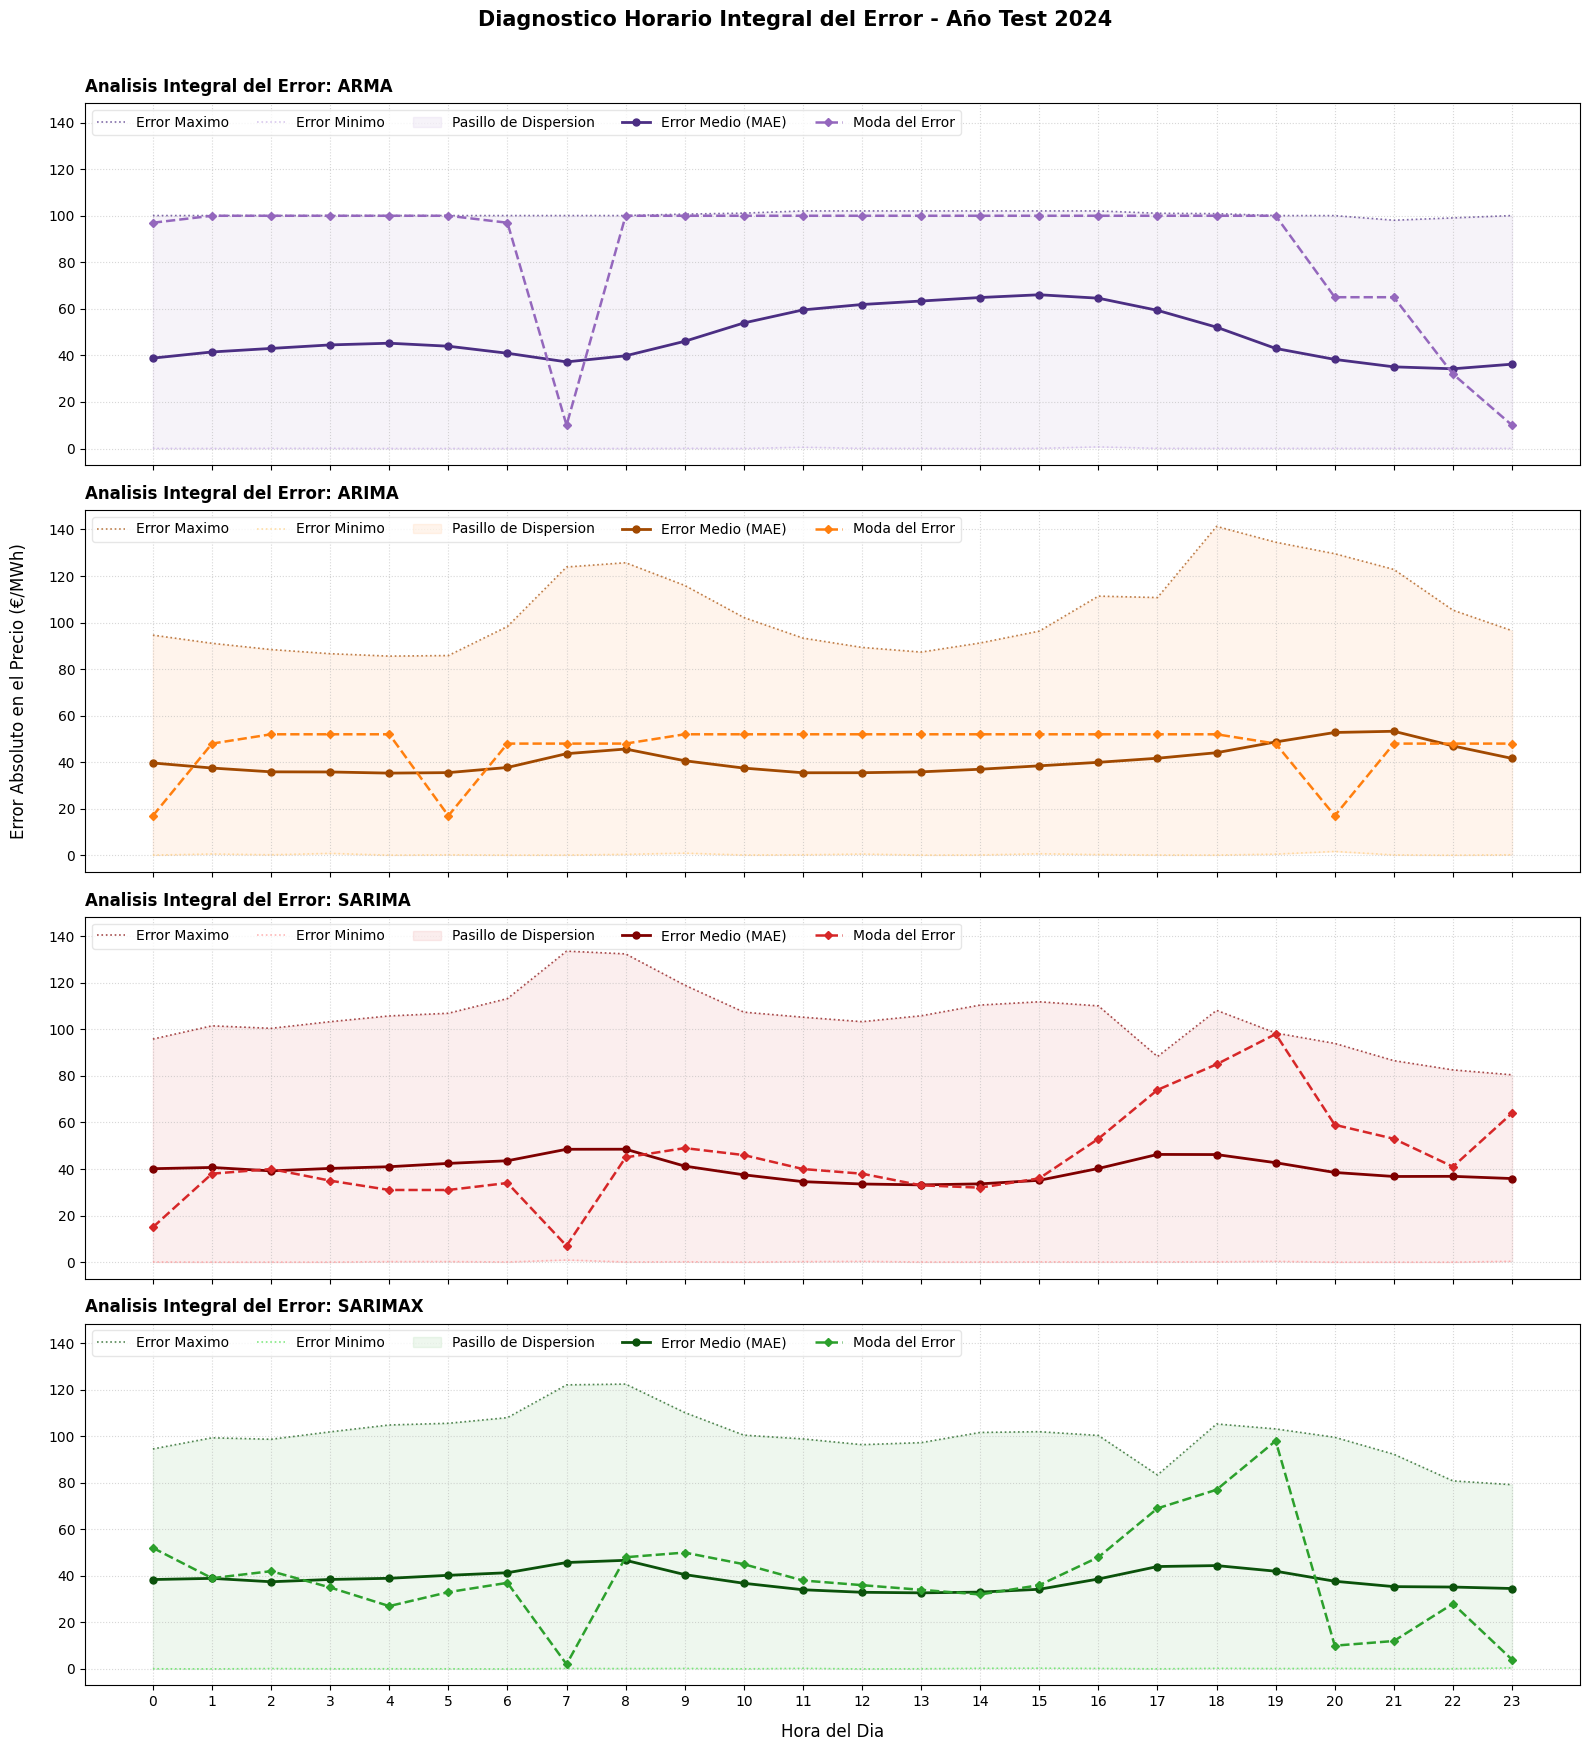

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error

# =================================================================================== #
# 10. DIAGNOSTICO INTEGRAL DEL ERROR: MAXIMOS, MINIMOS, MEDIAS Y MODAS (DESDE CSV)
# =================================================================================== #

# 1. Carga del archivo CSV de resultados
df_resultados_csv = pd.read_csv('predicciones_comparativa_series_temporales_2024.csv', index_col=0, parse_dates=True)

# Funcion para calcular todas las metricas horarias de forma limpia
def calcular_metricas_completas(df, col_pred):
    error_absoluto = (df['Precio_Real'] - df[col_pred]).abs()
    
    err_max = error_absoluto.groupby(df['hour']).max()
    err_min = error_absoluto.groupby(df['hour']).min()
    err_mean = error_absoluto.groupby(df['hour']).mean()
    err_mode = error_absoluto.round(0).groupby(df['hour']).apply(lambda x: x.mode().iloc[0] if not x.empty else 0)
    
    return err_max, err_min, err_mean, err_mode

# Calculo dinamico para cada uno de los modelos
max_arma, min_arma, mean_arma, mode_arma             = calcular_metricas_completas(df_resultados_csv, 'Prediccion_ARMA')
max_arima, min_arima, mean_arima, mode_arima         = calcular_metricas_completas(df_resultados_csv, 'Prediccion_ARIMA')
max_sarima, min_sarima, mean_sarima, mode_sarima     = calcular_metricas_completas(df_resultados_csv, 'Prediccion_SARIMA')
max_sarimax, min_sarimax, mean_sarimax, mode_sarimax = calcular_metricas_completas(df_resultados_csv, 'Prediccion_SARIMAX')

horas = np.arange(24)

# Estructura de 4 paneles verticales que comparten los mismos ejes para comparar de forma justa
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(16, 18), sharex=True, sharey=True)

# Configuracion de los datos estructurados para el bucle automatizado
paneles = [
    {
        'ax': ax1, 'titulo': 'Analisis Integral del Error: ARMA',
        'max': max_arma, 'min': min_arma, 'mean': mean_arma, 'mode': mode_arma,
        'c_base': '#9467bd', 'c_oscuro': '#4b2e83', 'c_claro': '#c9b3e6'
    },
    {
        'ax': ax2, 'titulo': 'Analisis Integral del Error: ARIMA',
        'max': max_arima, 'min': min_arima, 'mean': mean_arima, 'mode': mode_arima,
        'c_base': '#ff7f0e', 'c_oscuro': '#a14900', 'c_claro': '#ffd080'
    },
    {
        'ax': ax3, 'titulo': 'Analisis Integral del Error: SARIMA',
        'max': max_sarima, 'min': min_sarima, 'mean': mean_sarima, 'mode': mode_sarima,
        'c_base': '#d62728', 'c_oscuro': '#7f0000', 'c_claro': '#ff9999'
    },
    {
        'ax': ax4, 'titulo': 'Analisis Integral del Error: SARIMAX',
        'max': max_sarimax, 'min': min_sarimax, 'mean': mean_sarimax, 'mode': mode_sarimax,
        'c_base': '#2ca02c', 'c_oscuro': '#0b520b', 'c_claro': '#4ee04e'
    }
]

for p in paneles:
    ax = p['ax']
    
    # A. Dibujar el pasillo de dispersion (Maximos y Minimos)
    ax.plot(horas, p['max'], color=p['c_oscuro'], linestyle=':', linewidth=1.2, alpha=0.7, label='Error Maximo')
    ax.plot(horas, p['min'], color=p['c_claro'], linestyle=':', linewidth=1.2, alpha=0.7, label='Error Minimo')
    ax.fill_between(horas, p['min'], p['max'], color=p['c_base'], alpha=0.08, label='Pasillo de Dispersion')
    
    # B. Dibujar el Comportamiento Central (Media y Moda)
    # Media (MAE) con linea discontinua y marcadores redondos
    ax.plot(horas, p['mean'], color=p['c_oscuro'], linestyle='-', linewidth=2, 
            marker='o', markersize=5, label='Error Medio (MAE)')
    
    # Moda con linea de guiones y marcadores de diamante
    ax.plot(horas, p['mode'], color=p['c_base'], linestyle='--', linewidth=1.8, 
            marker='D', markersize=4, label='Moda del Error')
    
    # C. Estetica y formatos por panel
    ax.set_title(p['titulo'], fontsize=12, fontweight='bold', loc='left', pad=8)
    ax.grid(True, linestyle=':', alpha=0.5)
    ax.legend(loc='upper left', fontsize=10, ncol=5, frameon=True, facecolor='white', edgecolor='#e0e0e0')

# Titulos de los ejes globales
ax2.set_ylabel('Error Absoluto en el Precio (€/MWh)', fontsize=12, labelpad=15)
ax4.set_xlabel('Hora del Dia', fontsize=12, labelpad=10)

plt.xticks(horas)
fig.suptitle('Diagnostico Horario Integral del Error - Año Test 2024', fontsize=15, fontweight='bold', y=0.97)

plt.tight_layout(rect=[0, 0, 1, 0.96])

# Guardado automatico en alta calidad para el documento del TFG
plt.savefig('grafico_diagnostico_integral_errores_series_temporales_2024.png', dpi=300)
plt.show()

### Metricas Accuracy

In [36]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    median_absolute_error
)

# =================================================================================== #
# 11. CALCULO DE METRICAS GLOBALES DE PRECISION Y ROBUSTAS (DESDE CSV)
# =================================================================================== #

# 1. Definicion matematica de funciones porcentuales robustas para el TFG
def calcular_wape(y_true, y_pred):
    """Calcula el Weighted MAPE ponderando por la suma del precio real."""
    return (np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))) * 100

def calcular_smape(y_true, y_pred):
    """Calcula el sMAPE acotando el denominador entre el valor real y el predicho."""
    denominador = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diferencia = np.abs(y_true - y_pred)
    # Manejo de proteccion por si precio real y predicho coinciden en 0.0 €/MWh
    ratio = np.where(denominador == 0, 0.0, diferencia / denominador)
    return np.mean(ratio) * 100


# 2. Cargar el archivo de predicciones unificado guardado
# Asumimos que 'datetime' es la primera columna y sirve como indice temporal
df = pd.read_csv('predicciones_comparativa_series_temporales_2024.csv', index_col=0, parse_dates=True)

# 3. Definir los modelos y sus columnas de prediccion correspondientes en el CSV
modelos = {
    'ARMA': 'Prediccion_ARMA',
    'ARIMA': 'Prediccion_ARIMA',
    'SARIMA': 'Prediccion_SARIMA',
    'SARIMAX': 'Prediccion_SARIMAX'
}

print("=== METRICAS GLOBALES DE PRECISION (ACCURACY) - AÑO TEST 2024 ===")
resultados = []

# 4. Bucle unificado para calcular TODAS las metricas por cada modelo
for nombre, col_pred in modelos.items():
    # Variables objetivo reales y predichas
    y_true = df['Precio_Real']
    y_pred = df[col_pred]
    
    # Calculo de metricas estandar de Scikit-Learn
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100  # Formato porcentaje
    medae = median_absolute_error(y_true, y_pred)
    
    # Calculo de metricas porcentuales robustas integradas
    wape_val = calcular_wape(y_true, y_pred)
    smape_val = calcular_smape(y_true, y_pred)
    
    # Calculo del error absoluto y su MODA global (redondeado a 0 decimales)
    error_absoluto = (y_true - y_pred).abs()
    error_redondeado = error_absoluto.round(0)
    # Extrae el primer valor de la moda; si la serie esta vacia asigna 0
    err_mode = error_redondeado.mode().iloc[0] if not error_redondeado.empty else 0.0
    
    # Imprimir por consola de forma limpia y agrupada
    print(f"\n[{nombre}]")
    print(f"  - MAE:       {mae:.3f} €/MWh")
    print(f"  - RMSE:      {rmse:.3f} €/MWh")
    print(f"  - R²:        {r2:.3f}")
    print(f"  - MAPE:      {mape:.2f}%")
    print(f"  - wAPE:      {wape_val:.2f}%")
    print(f"  - sMAPE:     {smape_val:.2f}%")
    print(f"  - MedAE:     {medae:.3f} €/MWh")
    print(f"  - Moda Error:{err_mode:.0f} €/MWh (Redondeado)")
    
    # Guardar todas las metricas redondeadas para el DataFrame final
    resultados.append({
        'Modelo': nombre,
        'MAE (€/MWh)': round(mae, 3),
        'RMSE (€/MWh)': round(rmse, 3),
        'R²': round(r2, 3),
        'MAPE (%)': round(mape, 2),
        'wAPE (%)': round(wape_val, 2),
        'sMAPE (%)': round(smape_val, 2),
        'MedAE (€/MWh)': round(medae, 3),
        'Moda Error (€/MWh)': int(err_mode)
    })

# 5. Guardar una unica tabla resumen limpia para adjuntar a la memoria del TFG
df_resumen = pd.DataFrame(resultados)
df_resumen.to_csv('resumen_metricas_globales_comparativa_series_temporales_2024.csv', index=False)
print("\nArchivo 'resumen_metricas_globales_comparativa_series_temporales_2024.csv' generado con exito")

=== METRICAS GLOBALES DE PRECISION (ACCURACY) - AÑO TEST 2024 ===

[ARMA]
  - MAE:       48.067 €/MWh
  - RMSE:      58.925 €/MWh
  - R²:        -0.646
  - MAPE:      2755547602685919744.00%
  - wAPE:      76.23%
  - sMAPE:     76.69%
  - MedAE:     40.950 €/MWh
  - Moda Error:100 €/MWh (Redondeado)

[ARIMA]
  - MAE:       40.681 €/MWh
  - RMSE:      47.314 €/MWh
  - R²:        -0.061
  - MAPE:      1422532604648371456.00%
  - wAPE:      64.52%
  - sMAPE:     83.03%
  - MedAE:     43.762 €/MWh
  - Moda Error:52 €/MWh (Redondeado)

[SARIMA]
  - MAE:       39.862 €/MWh
  - RMSE:      47.140 €/MWh
  - R²:        -0.053
  - MAPE:      1228439857534581504.00%
  - wAPE:      63.22%
  - sMAPE:     84.55%
  - MedAE:     36.441 €/MWh
  - Moda Error:33 €/MWh (Redondeado)

[SARIMAX]
  - MAE:       38.426 €/MWh
  - RMSE:      45.298 €/MWh
  - R²:        0.027
  - MAPE:      1219973416925284096.00%
  - wAPE:      60.94%
  - sMAPE:     81.99%
  - MedAE:     36.010 €/MWh
  - Moda Error:32 €/MWh (Redo

### Representacion del resto de variables de Accurancy

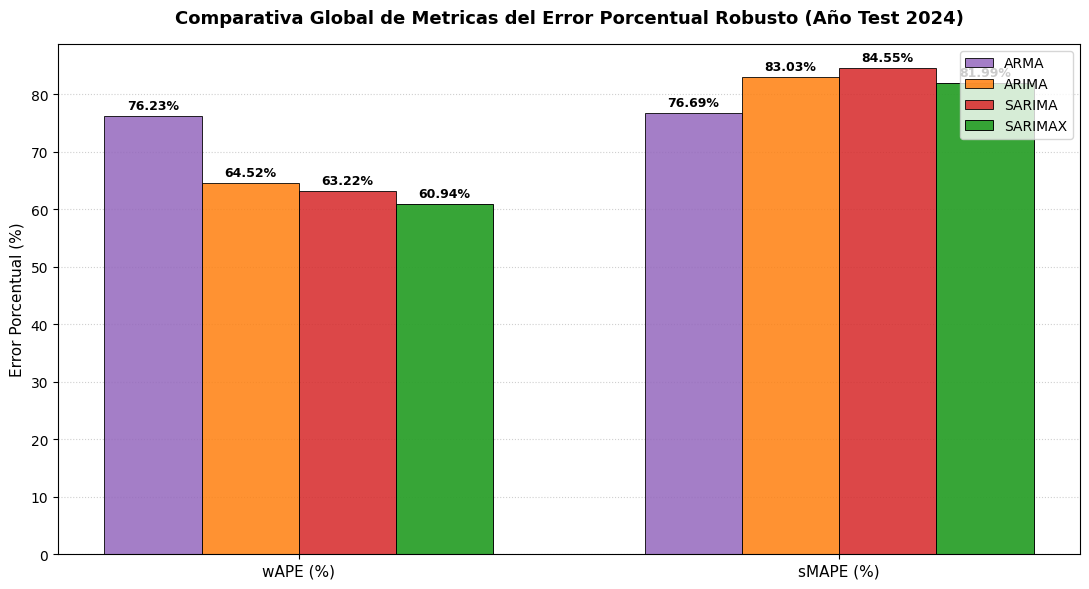

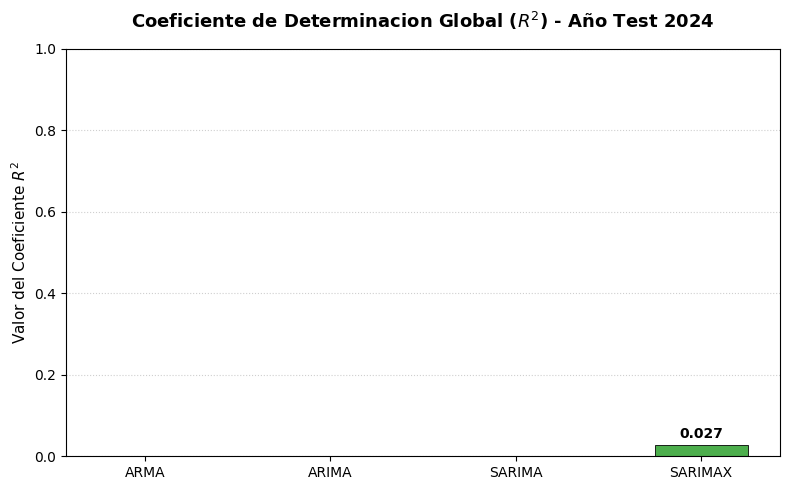

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =================================================================================== #
# 12. VISUALIZACION DE METRICAS GLOBALES DE PRECISION (ROBUSTAS - DESDE RESUMEN)
# =================================================================================== #

# 1. Cargar el dataframe resumen generado en el paso anterior
df_resumen = pd.read_csv('resumen_metricas_globales_comparativa_series_temporales_2024.csv')

# Configuramos los modelos como indice para facilitar el grafico
df_resumen.set_index('Modelo', inplace=True)

# Definimos los colores oficiales del TFG para mantener consistencia
colores_modelos = ['#9467bd', '#ff7f0e', '#d62728', '#2ca02c'] # Morado (ARMA), Naranja (ARIMA), Rojo (SARIMA), Verde (SARIMAX)

# ---------------------------------------------------------------------------------------
# GRAFICA A: COMPARATIVA DE METRICAS PORCENTUALES ROBUSTAS (wAPE vs sMAPE)
# ---------------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 6))

# Seleccionamos unicamente las metricas que no generan ruido numerico
metricas_pct = ['wAPE (%)', 'sMAPE (%)']
x = np.arange(len(metricas_pct))
ancho_barra = 0.18

# Dibujamos las barras agrupadas manteniendo la coherencia de colores por modelo
ax.bar(x - 1.5*ancho_barra, df_resumen.loc['ARMA', metricas_pct],    width=ancho_barra, label='ARMA',    color='#9467bd', alpha=0.85, edgecolor='black', linewidth=0.7)
ax.bar(x - 0.5*ancho_barra, df_resumen.loc['ARIMA', metricas_pct],   width=ancho_barra, label='ARIMA',   color='#ff7f0e', alpha=0.85, edgecolor='black', linewidth=0.7)
ax.bar(x + 0.5*ancho_barra, df_resumen.loc['SARIMA', metricas_pct],  width=ancho_barra, label='SARIMA',  color='#d62728', alpha=0.85, edgecolor='black', linewidth=0.7)
ax.bar(x + 1.5*ancho_barra, df_resumen.loc['SARIMAX', metricas_pct], width=ancho_barra, label='SARIMAX', color='#2ca02c', alpha=0.95, edgecolor='black', linewidth=0.7)

# Formato academico para el analisis porcentual robusto
ax.set_title('Comparativa Global de Metricas del Error Porcentual Robusto (Año Test 2024)', fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Error Porcentual (%)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(metricas_pct, fontsize=11)
ax.grid(axis='y', linestyle=':', alpha=0.6)
ax.set_axisbelow(True)
ax.legend(loc='upper right', fontsize=10)

# Añadir etiquetas de valor exacto encima de cada barra para el tribunal
for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        ax.annotate(f'{height:.2f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # Desplazamiento vertical de 3 puntos
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('grafico_comparativa_errores_porcentuales_series_temporales_2024.png', dpi=300)
plt.show()

# ---------------------------------------------------------------------------------------
# GRAFICA B: COMPORTAMIENTO DEL R² (BONDAD DE AJUSTE GLOBAL)
# ---------------------------------------------------------------------------------------
plt.figure(figsize=(8, 5))

modelos_nombres = df_resumen.index
r2_valores = df_resumen['R²']

barras_r2 = plt.bar(modelos_nombres, r2_valores, color=colores_modelos, alpha=0.85, edgecolor='black', linewidth=0.7, width=0.5)

# Formato academico para el R2
plt.title('Coeficiente de Determinacion Global ($R^2$) - Año Test 2024', fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Valor del Coeficiente $R^2$', fontsize=11)
plt.ylim(0, 1.0) # El R2 ideal es 1.0
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.gca().set_axisbelow(True)

# Añadir el valor exacto encima de cada barra
for bar in barras_r2:
    height = bar.get_height()
    plt.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('grafico_comparativa_r2_global_series_temporales_2024.png', dpi=300)
plt.show()